In [1]:
import xarray as xr
import pandas as pd 
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
import seaborn.objects as so
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
plt.style.use('robin')

In [2]:
ds_rain = xr.open_dataarray('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')
grid = xr.zeros_like(xr.open_zarr('/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr').mean_value.isel(var_name=0).load())

AttributeError: 'Dataset' object has no attribute 'mean_value'

In [ ]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe().set_index('track_id').sort_index()
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
def get_cyclones_per_day(line):
    line_extract = line[:-2].dropna()
    series = pd.Series(line_extract.loc[[k.startswith('C_') for k in line_extract]].values).dropna()
    return pd.Series([int(k.split('_')[1]) for k in series])
    # return pd.Series(line_extract.loc[[k.startswith('C_') for k in line_extract]].values).dropna()
cyclones_per_day = df_features.apply(get_cyclones_per_day, axis=1)

all_cyclones = cyclones_per_day.stack().unique()
cycs_lc = cycs.loc[all_cyclones]

def get_ds_cyc_lc(date):
    line = cyclones_per_day.loc[date].dropna()
    # if line.size!=0:
    full_cyc_lc = cycs_lc.loc[line]
    full_cyc_lc['date'] = pd.to_datetime(full_cyc_lc.date)
    lc_before_date = full_cyc_lc.loc[full_cyc_lc.date.dt.date<=line.name.date()]
    lc_before_date.loc[:,'timestep_past'] = lc_before_date.date - line.name
    # return lc_before_date.reset_index().set_index(['track_id','timestep_past']).to_xarray().assign_coords(time_of_event=date)
    individual_tracks = list(lc_before_date.index.unique())
    lc_before_date.loc[:,'track_number']=[individual_tracks.index(k) for k in lc_before_date.index]
    ds_tracks = lc_before_date.reset_index().set_index(['track_number','timestep_past']).to_xarray().assign_coords(time_of_event=date)
    ds_tracks['track_id'] = ds_tracks.track_id.isel(timestep_past=0)
    return ds_tracks
ds_cycs = xr.concat([get_ds_cyc_lc(time) for time in tqdm(cyclones_per_day.dropna(how='all').index)], dim='time_of_event')
ds_cycs = xr.merge([ds_cycs, ds_rain.rename(time='time_of_event')])#.sel(time_of_event=ds_cycs.time_of_event)])

ds_cycs.drop_vars('closed').to_netcdf('/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/cyclones_centers.nc')

SyntaxError: '[' was never closed (3272119622.py, line 27)

In [28]:
ds_cycs = xr.merge([ds_cycs, ds_rain.rename(time='time_of_event')]).sel(time_of_event=slice('1979','2022'))

/tmp/ipykernel_2237524/145558336.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_cycs = xr.merge([ds_cycs, ds_rain.rename(time='time_of_event')]).sel(time_of_event=slice('1979','2022'))


# Compute distance to cyclones

In [29]:

ds_cycs['tp'] = ds_rain.rename(time='time_of_event')
# ds_cycs.tp.isnan()

ds_cycs

<xarray.Dataset> Size: 2GB
Dimensions:             (track_number: 4, timestep_past: 175,
                         time_of_event: 16071)
Coordinates:
  * track_number        (track_number) int64 32B 0 1 2 3
  * timestep_past       (timestep_past) timedelta64[ns] 1kB -21 days +03:00:0...
  * time_of_event       (time_of_event) datetime64[ns] 129kB 1979-01-01 ... 2...
Data variables: (12/21)
    track_id            (time_of_event, track_number) float64 514kB nan ... nan
    date                (time_of_event, track_number, timestep_past) datetime64[ns] 90MB ...
    segment_len         (time_of_event, track_number, timestep_past) float64 90MB ...
    movement_speed      (time_of_event, track_number, timestep_past) float64 90MB ...
    movement_direction  (time_of_event, track_number, timestep_past) float64 90MB ...
    lon                 (time_of_event, track_number, timestep_past) float64 90MB ...
    ...                  ...
    msl_maxlap          (time_of_event, track_number, timestep_past) float64 90MB ...
    cluster_id          (time_of_event, track_number, timestep_past) float64 90MB ...
    bjerknes_id         (time_of_event, track_number, timestep_past) float64 90MB ...
    stagnant_id         (time_of_event, track_number, timestep_past) float64 90MB ...
    solo_cyc            (time_of_event, track_number, timestep_past) float64 90MB ...
    tp                  (time_of_event) float64 129kB ...

In [344]:
def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return radius * c

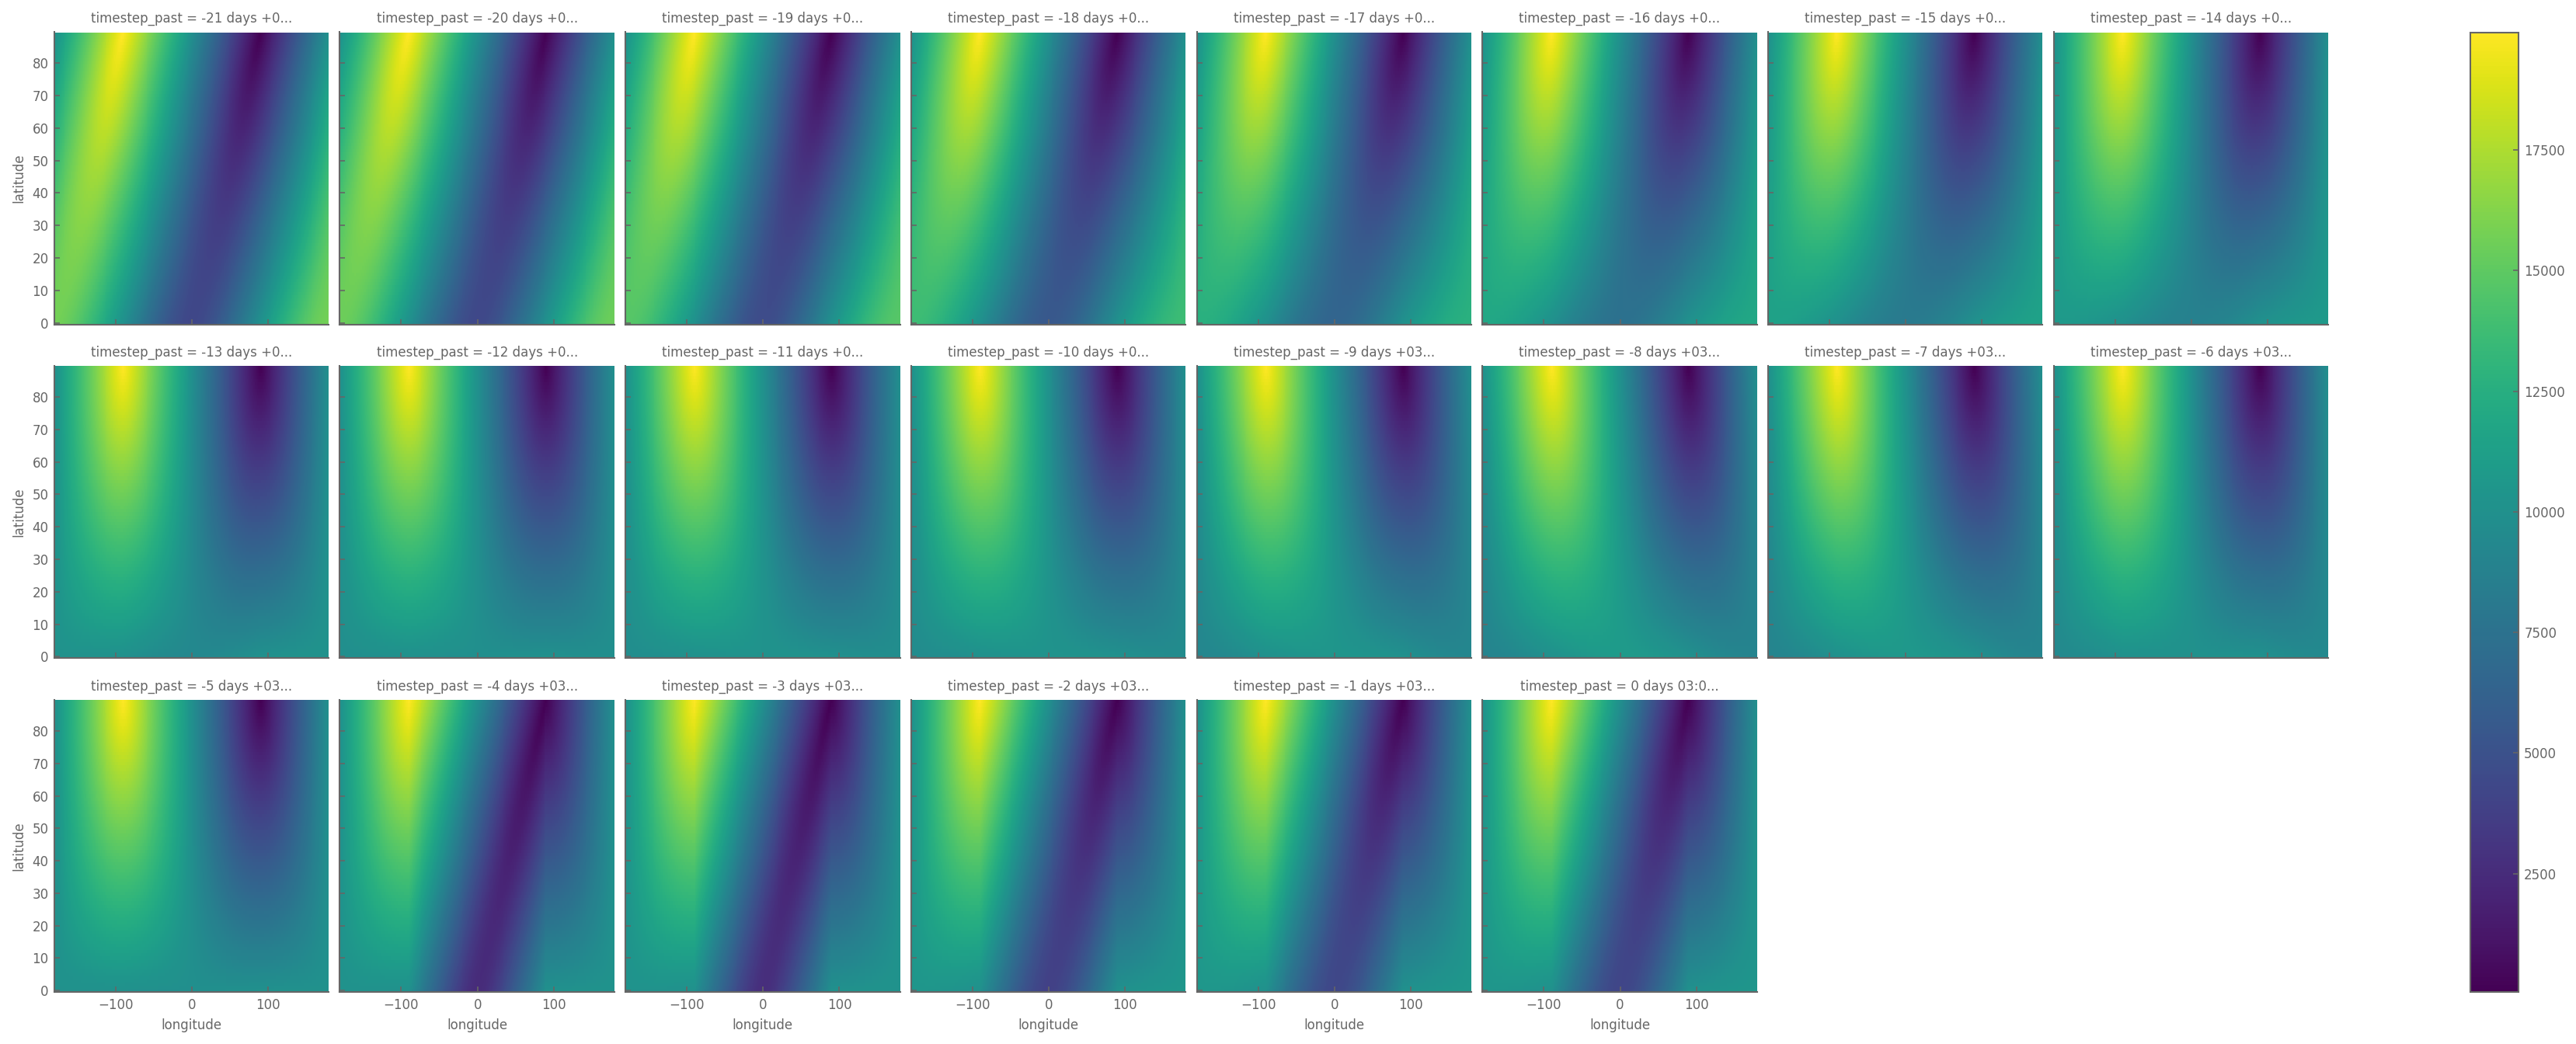

In [363]:
((haversine_np(ds_.lon, grid+grid.longitude, ds_.lat, grid+grid.latitude)).min('track_number')).resample(timestep_past='D').min().plot(col='timestep_past', col_wrap=8)

<Axes: xlabel='lon', ylabel='lat'>

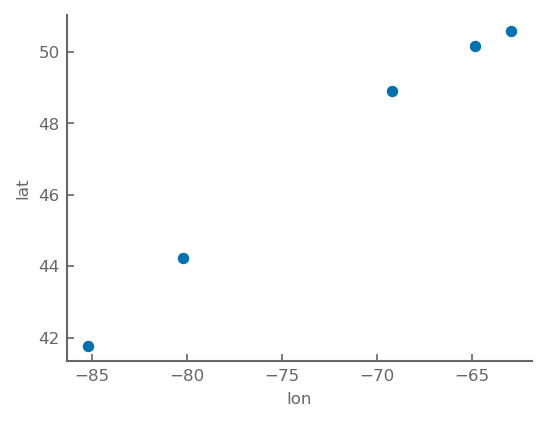

In [34]:
cycs.head().plot.scatter(x='lon',y='lat')

In [32]:
df_.groupby('cyclone_days').count()

,cyclone_time,rain
cyclone_days,,
0,6778,6778
1,462,462
2,1817,1817
3,2113,2113
4,1653,1653
5,1208,1208
6,808,808
7,509,509
8,323,323


# Repartition de la pluie en fonction des cyclones

/tmp/ipykernel_2237524/2917164563.py:6: UserWarning: 
The palette list has fewer values (22) than needed (23) and will cycle, which may produce an uninterpretable plot.
  sns.displot(df_, x='rain', hue='cyclone_days', multiple='fill', bins = np.arange(0,170,5), palette=cmap, height=4,aspect=2)


Text(0.5, 9.666666666666702, 'Daily rainfall amount in Western Norway (mm/day)')

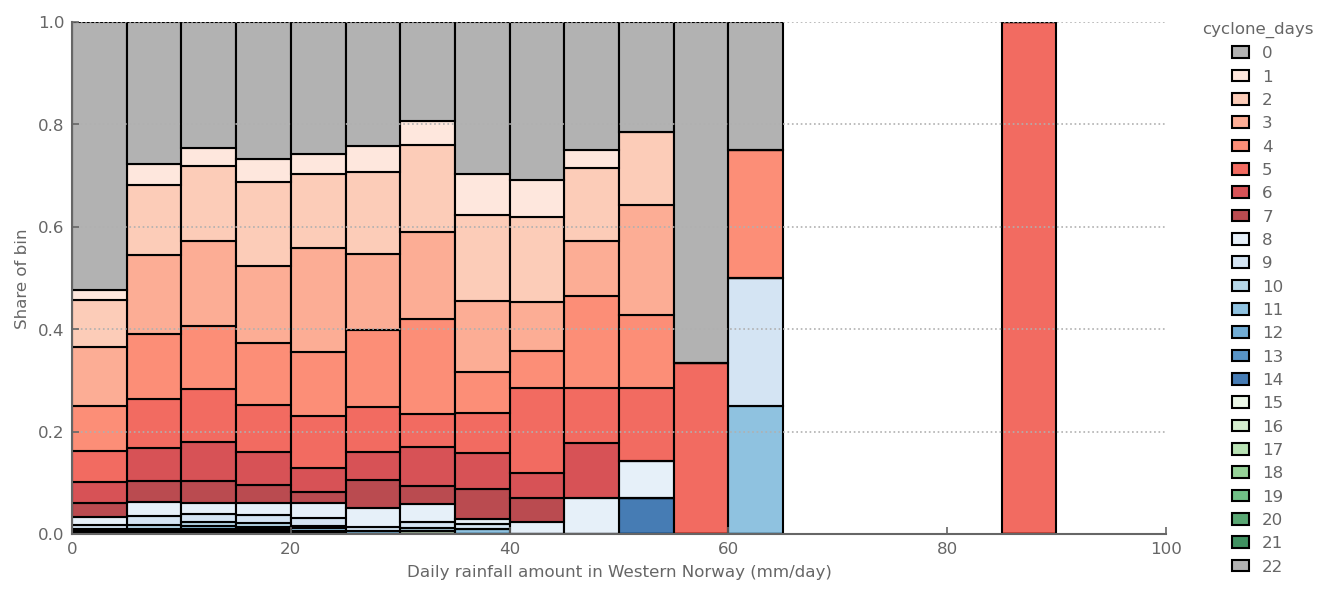

In [30]:
cyclone_time_when_causing_rain = ds_cycs.lon.min('track_number').ffill('timestep_past').count('timestep_past')
df_ = pd.DataFrame(dict(cyclone_time=cyclone_time_when_causing_rain.to_series(), rain=ds_cycs.tp.to_series()))
df_['cyclone_days'] = ((df_.cyclone_time+7)//8)
cmap = [(.6,.6,.6)] + sns.color_palette('Reds', 7) + sns.color_palette('Blues', 7) +sns.color_palette('Greens', 7)

sns.displot(df_, x='rain', hue='cyclone_days', multiple='fill', bins = np.arange(0,170,5), palette=cmap, height=4,aspect=2)
plt.grid(axis='y')
plt.ylabel('Share of bin')
plt.xlim(0,100)
plt.xlabel('Daily rainfall amount in Western Norway (mm/day)')
# plt.legend(ncols=2)


In [61]:
cycs

,date,segment_len,movement_speed,movement_direction,lon,lat,lon_raw,lat_raw,lon_maxlap,lat_maxlap,closed,msl,msl_prominence,msl_mingrad,msl_maxlap,cluster_id,bjerknes_id,stagnant_id,solo_cyc
track_id,,,,,,,,,,,,,,,,,,,
0,1979-01-01 06:00:00,250273.170667,23.173442,0.936289,-80.204250,44.223172,-80.091348,44.322709,-79.964346,44.445204,True,100546.372929,307.666266,0.0,8.336721e-09,0,0,0,1
0,1979-01-02 00:00:00,159959.622934,14.811076,1.144606,-64.830464,50.169664,-64.664499,50.652576,-64.041929,52.450603,True,100748.992025,121.332944,0.0,3.815932e-09,0,0,0,1
0,1979-01-02 03:00:00,141852.311598,13.134473,1.215818,-62.945528,50.597987,-63.559234,50.311239,-62.028140,50.046451,True,100752.120424,117.780303,0.0,3.454147e-09,0,0,0,1
0,1979-01-01 18:00:00,218399.557796,20.222181,1.089155,-69.209712,48.915301,-68.985598,48.996152,-68.011704,48.516583,True,100526.997914,173.628075,0.0,4.990530e-09,0,0,0,1
0,1979-01-01 00:00:00,NaN,NaN,NaN,-85.198857,41.775698,-85.319811,40.678730,-84.016848,41.857924,True,100896.454518,204.123601,0.0,5.676808e-09,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913771,2022-12-30 15:00:00,57643.662110,5.337376,4.164962,-175.392283,54.519681,-175.418580,54.514099,-176.483453,55.142310,True,97322.614486,227.340431,0.0,7.154741e-09,0,0,0,1
913771,2022-12-30 06:00:00,54661.507384,5.061251,4.341271,-173.051477,55.262934,-173.106174,55.333900,-173.924724,56.493322,True,97287.915969,197.652632,0.0,6.765229e-09,0,0,0,1
913771,2022-12-29 21:00:00,33491.388359,3.101054,4.519412,-170.786816,55.631568,-170.569609,55.571132,-170.971139,56.947353,True,97053.034946,165.987176,0.0,5.873541e-09,0,0,0,1


/tmp/ipykernel_2237524/960907448.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_['other_cyclone'] = 1*(df_.index.isin(cycs.query(("(lon>-10)&(lon<20)&(lat>50)&(lat<80)")).date.dt.date.value_counts().index))
/tmp/ipykernel_2237524/960907448.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_inde

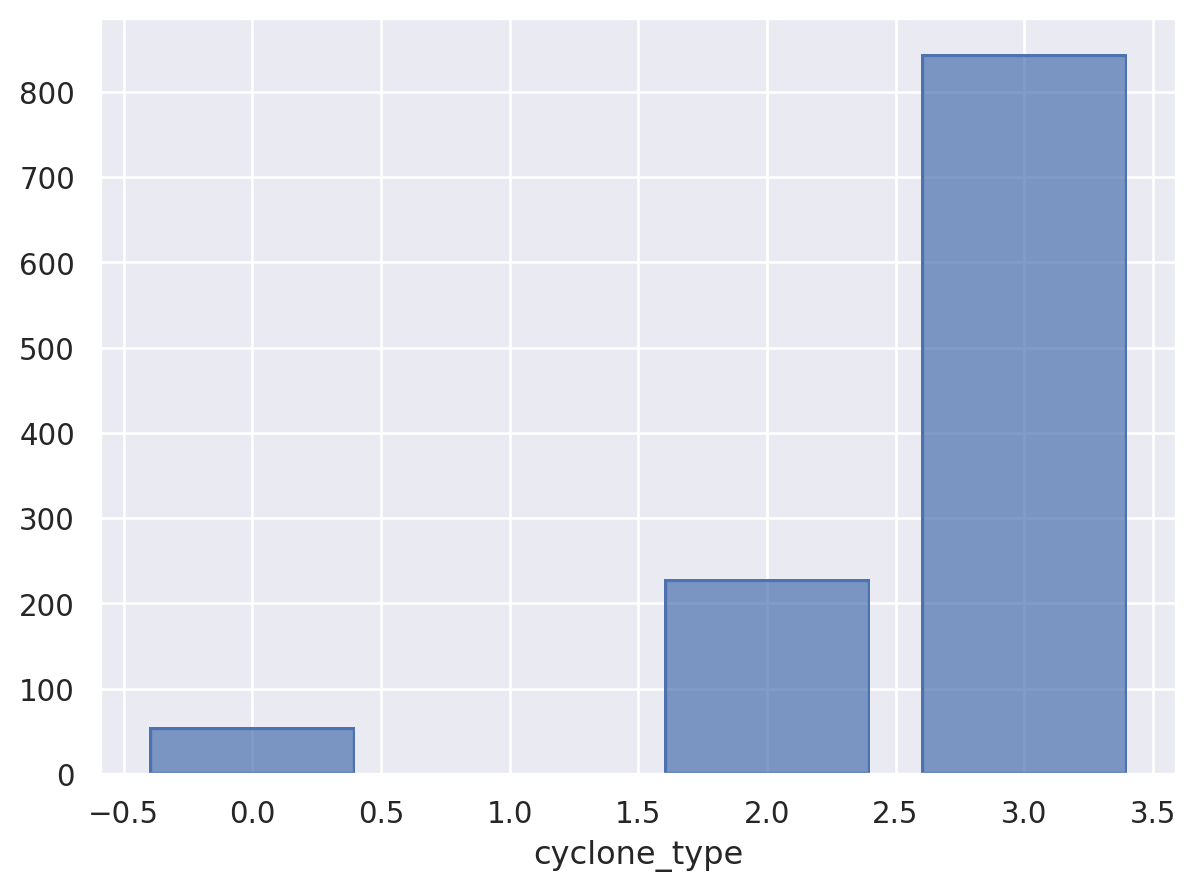

In [ ]:
df_['kjersti_cyclone'] = 1*(df_.cyclone_days>0)
df_['other_cyclone'] = 1*(df_.index.isin(cycs.query(("(lon>-10)&(lon<20)&(lat>50)&(lat<80)")).date.dt.date.value_counts().index))

df_.loc[df_.rain>20.5].other_cyclone

df_['cyclone_type'] = df_['kjersti_cyclone'] + 2*df_['other_cyclone']
df_['cyclone_type'].loc[df_.cyclone_type==1] = 3


In [128]:
df__ = df_.loc[df_.rain>20.5].groupby('cyclone_type').count()
df__/df__.sum()


,cyclone_time,rain,cyclone_days,kjersti_cyclone,other_cyclone
cyclone_type,,,,,
0,0.048802,0.048802,0.048802,0.048802,0.048802
2,0.202307,0.202307,0.202307,0.202307,0.202307
3,0.748891,0.748891,0.748891,0.748891,0.748891


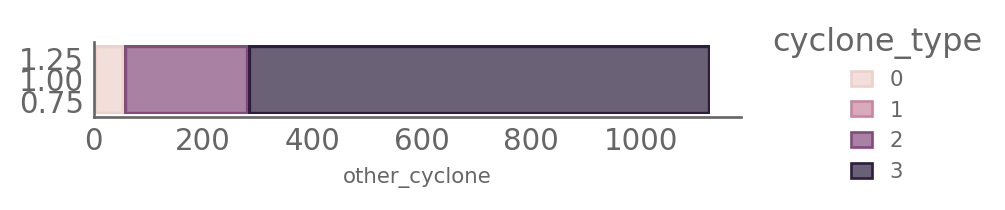

In [126]:
(so.Plot(df_.loc[df_.rain>20.5].groupby('cyclone_type').count(), color='cyclone_type', x='other_cyclone', y=1)
 .add(so.Bar(), so.Stack(), orient='y')
 .theme(plt.style.library["robin"])
#  .theme({"axes.grid":True, "grid.color":'0.5'})
 .layout(size=(4,1))
 .label(ytick=[])
)

In [74]:
cycs['day'] = cycs.date.dt.date
cycs.query("(lon>-10)&(lon<20)&(lat>50)&(lat<80)").groupby('day').first()

,date,segment_len,movement_speed,movement_direction,lon,lat,lon_raw,lat_raw,lon_maxlap,lat_maxlap,closed,msl,msl_prominence,msl_mingrad,msl_maxlap,cluster_id,bjerknes_id,stagnant_id,solo_cyc
day,,,,,,,,,,,,,,,,,,,
1979-01-01,1979-01-01 21:00:00,119428.295417,11.058176,2.691250,-0.844376,57.892280,-0.629599,57.999268,-0.486134,57.777699,True,101414.741739,307.672418,0.000000,9.309589e-09,0,0,0,1
1979-01-02,1979-01-02 15:00:00,18644.552734,1.726347,1.468048,-9.744396,67.451746,-9.611314,67.467808,-11.508324,67.568154,True,100115.500463,555.103497,0.000000,1.759875e-08,1,0,1,0
1979-01-03,1979-01-03 18:00:00,96696.604402,8.953389,2.113160,-4.594228,66.216224,-3.154843,64.895312,-1.388156,65.537585,True,99663.770385,283.626654,0.000000,8.420746e-09,1,0,1,0
1979-01-04,1979-01-04 09:00:00,85001.863277,7.870543,5.986432,-3.127944,68.743109,-3.569591,68.974979,-5.677417,69.537825,True,99787.956401,430.183718,0.000000,1.195522e-08,1,0,1,0
1979-01-05,1979-01-05 00:00:00,164783.335835,15.257716,6.098934,-6.464402,74.092275,-6.819777,74.221388,-7.105481,75.483136,True,100008.134634,262.926789,0.000000,7.581012e-09,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-25,2022-12-25 12:00:00,141265.595466,13.080148,1.144410,-9.293460,53.045347,-9.608808,52.681759,-10.487234,52.002651,True,99683.434912,250.447686,0.000000,8.331641e-09,9682,0,6313,0
2022-12-26,2022-12-26 18:00:00,130523.581050,12.085517,0.736830,0.162209,63.705238,0.416992,62.951368,-0.245903,62.497152,True,97447.615795,719.685992,0.000000,2.052303e-08,9682,0,6313,0
2022-12-27,2022-12-27 00:00:00,280681.122330,25.988993,0.362707,4.485210,67.684413,4.828846,69.721101,5.025353,70.496667,True,98100.476991,423.272263,0.000000,1.418078e-08,9682,0,6313,0


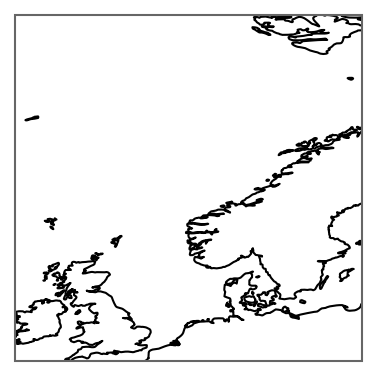

In [73]:
fig, ax = plt.subplots(subplot_kw = dict(projection=ccrs.PlateCarree()))

ax.coastlines()
ax.set_extent((-10,20,50,80), crs=ccrs.PlateCarree())

# cycs.groupby()

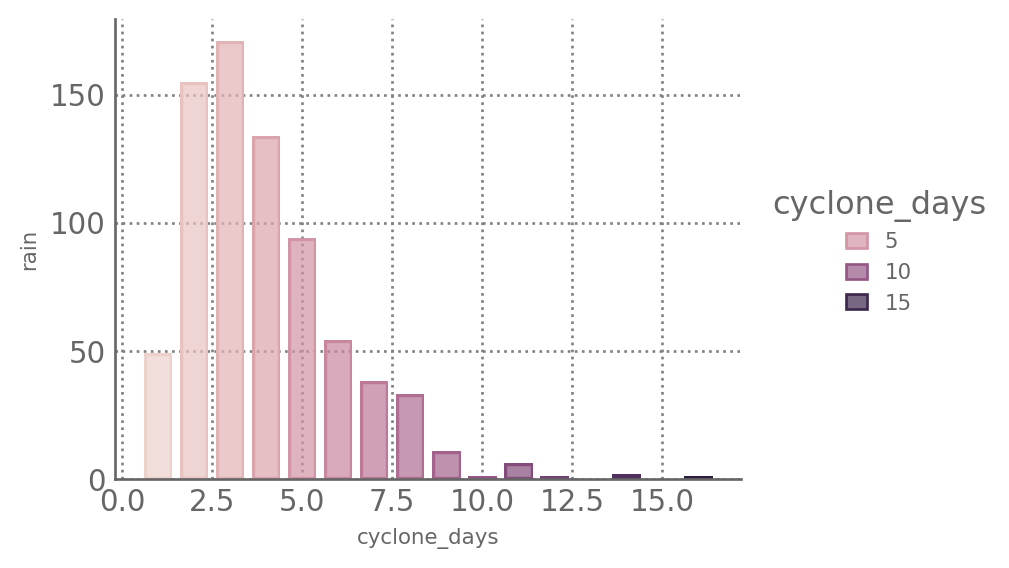

In [8]:
df_ = pd.DataFrame(dict(cyclone_time=cyclone_time_when_causing_rain.to_series(), rain=ds_cycs.tp.to_series()))
df_['cyclone_days'] = ((df_.cyclone_time+7)//8)

q90_rain_days = df_.loc[df_.rain>1].rain.quantile(0.9)
df_extr = df_.loc[df_.rain>q90_rain_days]

(so.Plot(df_extr, x='cyclone_days', y='rain')
 .add(so.Bar(), so.Count(), color='cyclone_days')
 .theme(plt.style.library["robin"])
 .theme({"axes.grid":True, "grid.color":'0.5'})
 .layout(size=(4,3))
#  .scale(color=sns.color_palette(cmap[:15]))
 )


# Ou sont les cyclones au moment ou ils affectent la pluie

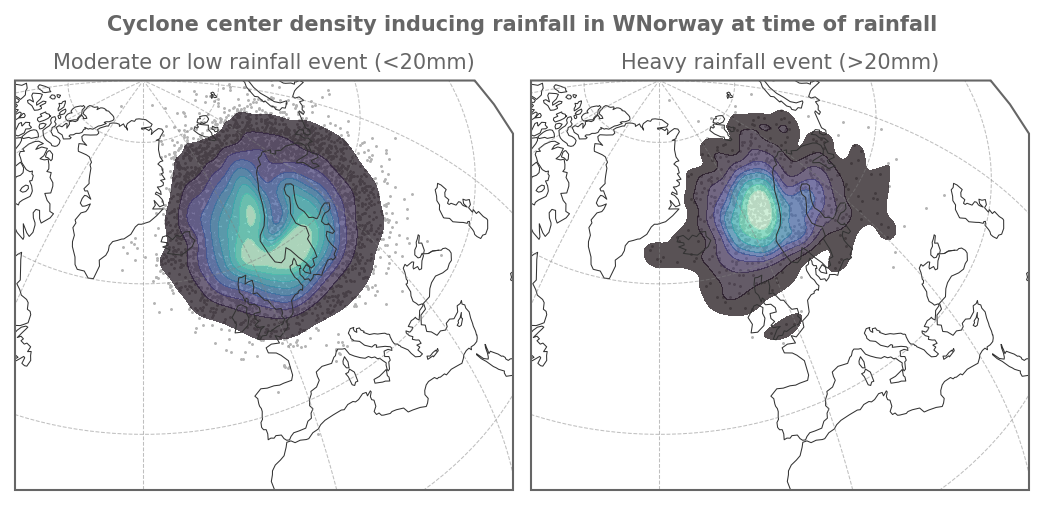

In [314]:
df_ = ds_cycs.isel(timestep_past=slice(-7,None))[['tp','lon','lat']].ffill('timestep_past').isel(timestep_past=-1).to_dataframe().dropna()
df_['extreme_rain'] = df_.tp>q90_rain_days
fig, axs = plt.subplots(1,2,figsize=(7,3.5), subplot_kw=dict(projection=ccrs.Orthographic(-30,50)))


sns.scatterplot(df_.loc[~df_.extreme_rain], x='lon', y='lat', ax=axs[0], transform=ccrs.PlateCarree(),s=2, linewidth=0, color='.7')
sns.scatterplot(df_.loc[df_.extreme_rain], x='lon', y='lat', ax=axs[1], transform=ccrs.PlateCarree(), s=2, linewidth=0, color='.7')

sns.kdeplot(df_.loc[~df_.extreme_rain], x='lon', y='lat', ax=axs[0], transform=ccrs.PlateCarree(),  cmap='mako', bw_adjust=1, fill=True, alpha=.7)
sns.kdeplot(df_.loc[df_.extreme_rain], x='lon', y='lat', ax=axs[1], transform=ccrs.PlateCarree(),  cmap='mako' , bw_adjust=.75 , fill=True, alpha=.7)


for ax in axs:
    ax.coastlines(lw=.5, color='.2')
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    ax.set_extent((-50,50, 30, 90), crs=ccrs.PlateCarree())

fig.suptitle('Cyclone center density inducing rainfall in WNorway at time of rainfall', size=10)
axs[0].set_title('Moderate or low rainfall event (<20mm)')
axs[1].set_title('Heavy rainfall event (>20mm)')
plt.tight_layout()



# D'ou viennent les cyclones qui affectent la pluie

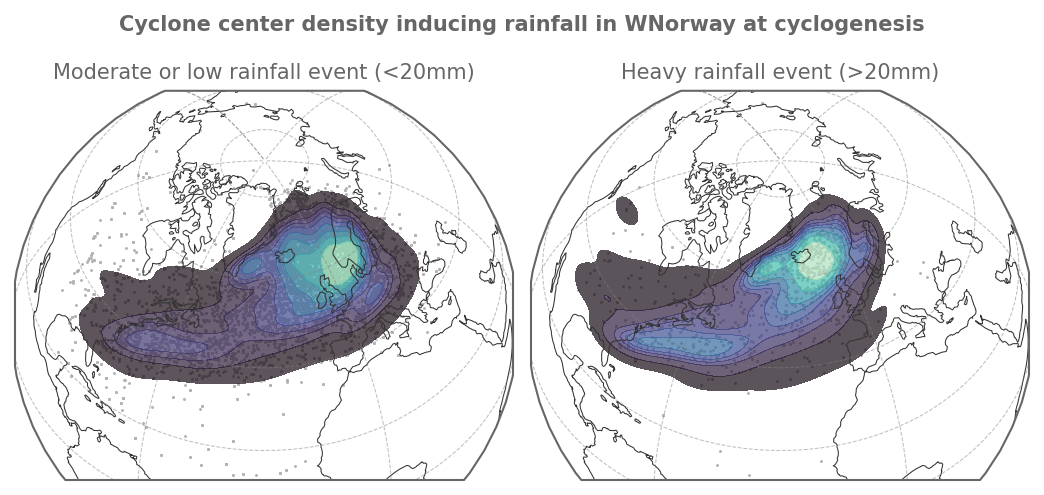

In [313]:
df_ = ds_cycs[['tp','lon','lat']].bfill('timestep_past').isel(timestep_past=0).to_dataframe().dropna()
df_['extreme_rain'] = df_.tp>q90_rain_days
fig, axs = plt.subplots(1,2,figsize=(7,3.5), subplot_kw=dict(projection=ccrs.Orthographic(-30,50)))


sns.scatterplot(df_.loc[~df_.extreme_rain], x='lon', y='lat', ax=axs[0], transform=ccrs.PlateCarree(),s=2, linewidth=0, color='.7')
sns.scatterplot(df_.loc[df_.extreme_rain], x='lon', y='lat', ax=axs[1], transform=ccrs.PlateCarree(), s=2, linewidth=0, color='.7')

sns.kdeplot(df_.loc[~df_.extreme_rain], x='lon', y='lat', ax=axs[0], transform=ccrs.PlateCarree(),  cmap='mako', bw_adjust=1, fill=True, alpha=.7)
sns.kdeplot(df_.loc[df_.extreme_rain], x='lon', y='lat', ax=axs[1], transform=ccrs.PlateCarree(),  cmap='mako' , bw_adjust=.75 , fill=True, alpha=.7)


for ax in axs:
    ax.coastlines(lw=.5, color='.2')
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    ax.set_extent((-120,120, 10, 90), crs=ccrs.PlateCarree())

fig.suptitle('Cyclone center density inducing rainfall in WNorway at cyclogenesis', size=10)
axs[0].set_title('Moderate or low rainfall event (<20mm)')
axs[1].set_title('Heavy rainfall event (>20mm)')
plt.tight_layout()